# 🎤 INSTRUCTOR — Team Missions · Answer notebook
Student copy: `04_STUDENT_team_mission.ipynb`. This copy has **solved code, ground-truth numbers, and grilling questions** for each team.

In [1]:
#@title ▶️ Setup — run this cell first (double-click to see the code) { display-mode: "form" }
import base64, gzip, io, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)

# The survey data is stored inside this notebook, so nothing needs to be downloaded.
_DATA = {
    "clean": "H4sIAAzivWoC/41927JkN47duyP8D/6A9AkC4PXVM47w+3xARVldI5fdkjqqpLD7772JKzPPJnMeWq2o0mbyAuKysAD+/POvv337/c8v3//2+MePP3798fW3xz+/ff3x+Prrt8ePbz+/X3/5y7fHz+u/+ueX//XHXz9+fvm/3779n8fPv3/79g/5g8cvX//93799//3bl1/++sfPL3/7+s/Hzz9++f71719++/a371/1q/nH//j6488vf37/7duX//3H/1xH++WP3377689vX377/vv1fz+vn7t++ueXn7/88ePb49v/+/qb/Ot//k//8m//NaUEj//++6/XD3778f33Xx/4gPGRHv/jj59/fvv7g9JHeZQPnH/8AQ9M118hXP8oH+ORywfYIPj4169/fv0v//bLd17h8yhQPvJj/g8e9fpTaPMf89/aNXLBj26j0OO//fXzmsrPn9d/+jJCu76lR3rQ9U/o11/N/+VrgDpigPy0FpIJ6xhYrzHaNYvrjz/6I/Eq5jDXHMZHtiFKzEG//xfZzx8PyNdvz2+AR8C5jiLruHajx27Up2nkByJP47drY+Y2zJ+cC2lzXWlObK7kWiB+FBuiPW+ojyFLmUcyf3QupfFSgHg91wpzbEd//OsldL/+Pj+Hp5XQ9XG5znZ+A3O89BiFR+hzBJ/GeBGOdUNpbke9Pm+8Fp5F0lOt7aPpGJCel/JyKjB/8fqCrkGyDMBrmZtbi68F4NOGPK+ofNRrE+s1R5r/nENAmXtWr8Fz9SUBnmSkXXvCUnmNUnhJg2XkGjt/JBuCbF9JZsFHe4khi+gluX5L5sf8L8kFDHII2POpXmuvchy8FUk34RKKR80uXFA+/bh9DddE4SFfmHjPi9pL/Hr9dMVWoWgsAMDSyLLZC8+CHq3F8tvTDj7fVBShSFNWrkXw5nZdSekhFP1uDJ8KTtmco0ypGLyYPvgsr1EW0RqLgOM6gHxfroGnIIhQNZXNFtPA9DqN7jcVeIgpmHnu6lzSnMKjXFJmn8NhJ66hpkA0vqRJtvPSIHLHyqXGbBB8Eoj1SBtrrMbatz5sK+e+1rijSJ/ul8skEstzXfaRpzj/qHY/UczPQ3ySjHkB6jXtzOqXJVMEDOYww4Ypr1drWQxOrTflqvAF5f1MfKTtkUP/Yn21JE/3E1m6CovoNUtUyerzjzEGaffHKmPMa9Z1V1H2pKkGvo7Fz7YfbgroxJOvBRrwGNc8aowx9uI1Lxvf9C6Ds67KUy0XP1pKMQc3qfPjeddNvM0sy2bSPBlTmgTr9+tGgmjGyiMUF62pwy5dZdeDcGeQBwtEY0s4WEcW3cIWqpbo5uev6UNnOzoV3VywzDyb+biEweSS3sjlJV8ksuziTSKXdZVL+mzTeR6s167LdJkddQhwmA1s8XXdKey5f9NgoJwCHyCyisAPtK+bqSh8FSK9h9NCUKg4vrGhYqjfzD3MBftTrqDEVvVpd1wExmIu0uvvT+sAbC/Y3PL2z2nF3uUU83/5Htknq4sTMorKcA/DneGg3kCuQPPZTyWzSFDGk0aR/c88hCp5uZhl1a+ZnnYQni5B44UTX2PxPZC35bISw69BzhudNGV5KkSdAf86X3E2P2F1c9lOgaX3GoLYeXFl1F5mUG8vgt2mwqcud5HFuOmFvHSBCWJud35+nOa4DmNKPopvO8Wgz4k+KIQp9zvHdh2judUmMXa9qQt2nYgPM+5DjmsxJCIoBqtJlEDJvLjuQ5SD4Ra5bLylTSxms3ghdHOB437wBkwBK76rwLOZDm8F39aCt37pZx+AFqesymUzl67QrXytjpmMMq2Vyg8HDTg3JVzDkk+285LsKWqD1R2uyvJaELmolXLel6lo2YbLjatNb+2l8+zGlXofNczDuTQL68ypsOTai96cKwy/rLSd1hofxFZ2iimJU8UhGF/ZFlPoNzdOvLorOGGdPzePxya02xKhUxkvoVMcKPAmTqW7etl1am9TW/XObtv3dEni5d3zUfL6O2t9/nk7yQqf7nt/OgXkUKHyNLIoHipuQcN8VNweBSHfDtlKOYqS+SiArbGNQHvVcw2W+V6Jd5hsFnODLn/INrPmnZsOYoQyB00kqq/Yn/Xst6yWu4iLeC+RFZ+qG/Vur48j4qpHl5Iv1wycM5s+vlcS+kxJS24Ia7s3RSLU6KFCExPCfzu9zNxiH55dyv5yx8WYJXYmeGOauGWwurZ13LuEGv+bFZBLZSb+Ok77vh2jcZj38JH5I8QFIbmCJxOpBrdYzxosDN4N4EiF1yCxbFkjwIYbuRLbLucI7J/msO1zhy7DaofS6C6Y96mwWUS3rBkUq7lCSJOslm9vmu3H4OveWF0p7gRVY7ASGryVI1yTeUcSuwlFjor/UQUp8bOpe7sI1w82RhfMXaJi1gRiHq43nzyE+Z/zNR8q34IrtKm0fSv7J42nLvIUhuQ6ggxo6svyxx7wSrz2rHiAO9kMslQfoaf9CMSBOLDKloMkVOlYwMMOx1tuiGH1UJqv6dzMGpe8485Rm9ew8fUCs1tVnd0FGum0t3wcVsw5c8zH8lgM58p+LXo+41w4D1ExHj5XdtLmH15iYPanlwPGNPhABRCA/ATahafX6wEGTQzntodgW7yPMIaZjhpraVsz2FSIkscu0FVHtIh/+z74EWCja+yV1Kma3nQLILaPI/SIi3NGciOHadzYzJFuNnPeKgafWUVNd1/UZbIYJsX3n4Pw2MoZq2QNwnQZoI7n5f7bOga+cRCnoWGs8UGmFIa5duGrDjqDbvNcq5ogVNs89JJc7rsPk+80BQAHEBZP8tA0WDYZkzChGOXoMA9FmmQOC7ABq6YcdRtUZl7EUGgk7v30FQIZGe00C1U5At0F8JYF7vJ96HvgDYbCoIv98ughrtkY54QFPVTr8WEMzXhcVlSNMaR0a3jWMx2+nzKPIUBPnkc6bJjPQfp63btHyXpXizlIgdBDwnuXG5BtKDzEy2c/k9QQN4yV0AmKhQdjj4JTUP4UQ0F6DxXJKhSsaeaWzFWEdwOpnMBtgZWzyfiSeMHFDEOqnxSfT4Q9GA74DTrMZNqrm9KA9NmQqxnqLIrgQCxUc5fdDEHqJ/yzasYlMy6dFuwu/ExI41a4A2Av6o0BZwaTIZh8f4fdEYC0rKO/BnKFs3HzorPygq4+UXftCQD32B17qhbI5QikslgQss/xHoKsrmYsDGO/Zuqq4mlNADr6qE1zI6stlYtRFggO4BiWd5aHwmh0j1QeizjGPpZX/+jVKwC2p8RL4GvO2mducIlR6hYMzBwFudrk89BM76U4KTa0nbYEJLzvPI8SKcF50Jdj4INsonPJvhVV/iMSJjTP1Pdz7Jy0xpIt2QFcMMXrmBzYB0wbtW2qfwaV4yFgvt8wzoA4xHFtzTlA1yCosKbANQjCJbgGxHMspUA/saulw5DmFLP77oD0KbC0AwHV/+CC4RbR8UnAfU4SNSEqAQAuIGtblT+WXap5aCYuhSllHT6zlcv39QUicIg9eTaxL3ALTr/Xl98+TX/NCzdhK/hNr7aDiwHEvvEHJAABNhNT1SnACpZtD1WD4+6KhtIdCpZ7QtOC0exDUHq5nxa+scs/9YMAolm9zO5xA9Cn/LhPXu5E6EnHuy5fxiSA8JDox8YZM1x0FG/ytL/++3QPmA2HLl29SQ6zTpzf7iTlU/wMTT1tjZ8ZpyFHuyBWUV6vk6XmiUOvFx07zzWyuUD17GVz8nFuJQX6KShPXhAFoPbmMoIiI3yWEsNN5dJCDPom4mjqyMZt8DzeFS3457ekDV8GTU3CEQuHjeIh81gzwesuMuSjnoR5rxcvHeRS13m7fATYqpXBBBZiTa3ouuOoyU8k44GbhKBhaIDRFlUuDnKmsytkfn4x19bcqeoBD+S8S6NaTI8e0wOEwfLvy0sOUE7Tc8igxq4LEpwndmqKKdcXR3DFTuMcUW6FIlw47Z3dzNzeIArkGJdpCMaBm2yk3a373I/hn0mZVR60ZYUeS4sRdtG4uHOFtWFIVDb6SvNYHEra8MwEYCH1a8WZSRN7dVtnh1FgC0oAqzm5XksubnqZzeFkKLgdoCzGtkaGZU5n8V8K3bu0mJSghs+hAQmpwPcg7/PRTe0U+6NlSU5EAH7FbndGxvw/cYiL0/Tm9+EQv2R2XuJVgbDbCnNm9sFgLsT3r+0xsswjdM7nK9yY7V63mEXfWAsRJFJ756rJUnnXJtq1KrfMjDX7F5paLrYCKmNiPCZLa57nRbOg5rnIV9IVs7yiPNPUdR/cgLIzQN1oAkMb40rWO3qG2HxyP7gqPaRbxO70Cqi0D1NBchpJM0wujMyZCJtZ88ZUCeWzPIT4yX/h8dJ1Dr6EM3A+NFSF4NmQWtwanletGwxfssH1MXgIRxpJTyJIilDbyf8pDP42pfZ5VMMkypCp2k9oIyMuzE+csZoQP7sqhxIBc91A6ZGOKJrC7SvjgfmnNkZL9+BB091M7sfCkmsz/dLgzW5WHUJ3UmKCmSyLE5nJnbsZwLQwCgQpA1i9eU8MQaMdtscApWk3NO+nyaUw7dryPYAzZz/3yeh4PWL+Pg2FnWIrO84TMwJZBizjanyZHtBPq7e2Xjhn5SEheTIHdl7PBbdpW8DcqRlDY3MwxRp+X+tbx5MdMwZrJJZRAebAFuPkx9ZfKwoNh6NT1H1pnqWFnk50yKaCGjqt2+574hv6u8T30ORidhmuVTdy8Xn6G5LvEO/mgUpY0Wxcm56P7Uank2oqXV0kfAaqGf8KW983jHSBiIWPIeQ1xsuNy3jF9r6UcoQrEqv6zoJVFYPqhh+VWEw9edKFg7RLOUguojlKkGc23uSrtzvHARccEJ8JDSOclt73jhvTsIyD1cJg0xqc9bFNv5ORQheTP39+Oo62iyOd9Dsyqkornd78tisMsDUMOGU5u6ajTKSqBRJBfILxJp654tUekciICgnbhXGnG83cGiG0RZRfxd+w2zXyHuWAxsCXZNwxMsxTSrPzAWGUA9Yy99GI/MXiiCKArs+hHlP2NDWlZk1qYPSwGtrR7v0eYBheU/7EV4DcQkRUOU40jKxBxDwDJS8UTZYv7uMY2xggs6+Aa+LHaM7NU6OYzsG1sIykSiQ9ERPbgtrgp9qdF8CiKz02DH5HYyc69oUviZtnXJgFUItmXKsIy7SiHSreVu7I1SalyBrJNSdFXiKdhy91O68Rql7wmbQGrvJg6EpphSPWsc16N03eB26iDEkudvFZ1BeS0ZKzEfxIzJVg0kmNV1QTYCRt8qcBug9ACuIN41G4AcbU7yHEqWGGKrkSyLpBDdU9CEzjkMgjzwXOaFvyqkXvR1AQENKGtj2/lwoTwzALWoxO8Tm8MIbVTHTl8zC9FIJ1j/NekH2M7+Ea0DS3DJKNCuJhGQLtqVoWWWUpICjmiXUh9Pgi9nYbm/pC5DccDXaZWTEbodwj2jOuMjUL4QmyO+GAKN7U6ZgjKWw1eATdz2t0Uuxj20oS8ZYzs5XWzBlrhbiTLxU69BoRpQfvYVlxkrEQvBDGtvigMZlpClJVpSI6Zcx7bToF05YNpfudtExLmDzGXSwOpOLn+hyPZIBjAQViwcwtSf2DnQLijUctNyErS5mJYGtKO/gviLS1EiihhN0jp3wvv523cydJytDC+CavPnFvA7G8YW5OrVTc5amedgyV+FqN8ykc7SzL4vUI7xFVEmqPY2i7GgIBKtKSHALNp5clpkPsW7pH5/ROUYRAVILtaIBmiEcmEPSFNEIBYKJYOZsGpX0dAIqCo5W4QqafQ6gJjt4PGJW5CP2dJHWZGMEgTz8i4cELY7YfRWURkOGzQVFAolNlJ6mWjEpEcM5F802l/CZhkpQuIXAe70cbhnnU2NeyjZnNp1XfoVuElePjA9dCGU1t8Wmz0as6xG62DXMFxBdNvpNd6zED1Ubq26LlzOxoYEx1Sddw1UlyQ0H3orlikaSFpew8oNZIiXNPfqI5HbItER2o4c8qErNszQY4VYIza6RrJlqUPhsBLk0orvIyfjL+z6U2yVPzYLyuHhKVbytrpXCb1BtekkUwwwNz/3L+JEVr1i1p+nbYzLVOyT8vbwqMDXkgvtMpimNXHhLmeiyR0ZrpseDCxeK86nEe5vaOFzaNpbiCypqRzFH2RAfm/ilcV2d4KOHkyXozFBVe3Guy5gkFTBzjSjmo+DDZa9hjiJKO8LJUGUtoInUYphqiuBULHOBQxmW7YtQLHApqEX0i+AZUYmBP0TWm03r1T/PkMhY6Ugabln+TEz6KQsQ1NF15pzGL8mckjp/nMihSOD5MeUN2E9JD01RYsoCpS17Th6kn7jsm6/Pg3NRhkfAyRttqHal9kvxk8u+nUmwYu9rvbjwkzUnKtyKgxVJpI8Rjj1hmRWTAfx2NiRTMWqzp3kuH+qR0U8BqOPWVWY4K78rYu9pRIxOR2Z8SSrPiARxjNcWK06u2ehBi7bJX2nQFYEhGcvs9+AIwq5XsCGo+Nu8QmLJycYux3LwUo8UiyoHm3NnblLSBiFITEg4sJQhY64lB070gzxM5oFFDdrId1hMXyLiX4taId1WMNh6Kq/a7+DFOVYaBRTbUw2ISqOnwOo6VJY19I4vCnmtPL41hB9vSAZwZzB5vS26rSyTRl14i2PY0DCHFtqUGuWkUtXjfbVsUAVL/1Rb5VstcFg4ntpOvyW1ZzJikcJybBDN2UVven2vRmj5k10QomGDKd9mHsgvHunoIiTUdSxq41x3au9UjHZQUF8OHlcUpKSYv/TvwNscjUFnSSZh/QcW4QQGQtH5MB2Svy2ePO1tSgSs0w9Vr58KIrtlvmbz4eVk9rshVYk8bZy9rFXYQ5qRyakpbTKLD8YJ0ZjOgKvBihUNc+eiV0djxCKQKJUGYa/mxXLK8xhAvZTufSPTI6suYNq6+WPV4Lht7PqgvmjuR1Zoq60q5X8hBiQ1SNgg/12KDRxJUjQYawWWvGw9YIenkptBveaDAvb2pJKiqsMKc5xqBtsln74ceTshOyXIWzWqXRgwwDl4jfaBX/xazRUMzccsle0n3vFwS1MCSnPBkGa+ocsEB29ojgxxjP7v5aOF+D9wx34kx7GKuL0bRDy3JIhx0NMtGKM2OaQ8HBEMkxkkmcU6ZM6nW7ScKTHwWZc+18QIqIUwxps5VcdMukefucNQDvVjCKQmH+K969PkxmRjt0ASjaT21YWmKQNFSXIKjH2DxzkZQnDRQXxMsvg4sbIwdCMXKVatCFEiEZBWWjghTSmdsOyv5zFP0ZMfhiSdKb9pgodjCsaiq6Gni8DYlPFW5DG2bQN4ZRGuBaUa61cagow0x1EJyLrBU8D7PJL/p92Pt0p70N+tfG6Gc7gmzGy0UypZUVf66XzbatWyLmgAjJ+q5gHVLC3tIqZ3TcST9TqarJaQZ/hHt5uAb0s/5UR6khKgOKysr7nDRa/HOJ4++u6iVlUaclqZQBGnXuaa4PTFKPSQ0uNTL3em1ZdtNzYmka6tbtdaUOhBNkAjeFD9KR4hheWew5Jy2hrDDgX1zwcROQlqSlMagiECVzlU83n1JmFledqipVh9k3whGGkP0h0prNILJS16HbvNCZl7hoR5bNwFtQtDxr889YDivwIfLgY0Uu1ttWFkOtu/za0MZ1ZIbalG/WZdqAVpzQ5/cPlQiarYGMO4nVS8YJzz3MWhahrWIeLLERIgWwhufByxJZNVIXjbQYxA8dXiSelqLjqLDEsb3e8E0ZYVSoNxMKLp4oHasmI98WLlkgUtJbx9FHm2Icpe0tX4+IMU/GKwUZhL4WdQ3MYn08lvShUNr04p7z4Tt5D1LGevQNE+0+uBOYmEesZ8gbPSaLMNelYGZ53n6GONAoxtaLhCKT6sGgydEtGcFk5c9kFlVSdc0Z28SwT1uy9mIpkhQj5MEqaO1kyTcFgxYhTwEhaChRqi9xvxpN4JwEIygzhommud4vo8on3JLwxFwbhDZLbmUhSZuQkXlDK01wWxZSXjbmHnlqccY9R4ViyJztCxb1ZC1OxxFdMt340hDJTFFNmFaYPvuUCmRWZPgZ55WmSbPRWAceg/mD0F10dGnRgYzxBA5vWl9AM6UWisly9K+kDLcQxVVMyHyMeMeSi8vE4qz/Xup3nn2qWgsVci4trCF1d7dNm8TgNikyPhyhNpxJ3o3UD5JIsMcxfs/LL2o2tKEkHJ5Q9VKSq31bpKmVGyAepgEdHfG0GjN6D0MMTaivSk4HQsIpgzdovXQl1j4kR4VpJVfwMMaa8KwNjU5NmTc9n8Ql2FN15L124k0G5V0EG3m+UVXqxLdoGBpYksFDl6U/GJU4Ei+VLo/+AB4YveAt35ogVIwk9MTD3RbwxNJKQuKaaXX9InO+j7kbUgrrWbokaIloGmY5og/lXe84K4lm0VduRrIsO9DvbP6kJTuBk72RrDK/FCPpe1KdkEZ2mSq3XskRNKdyps4B9hUJqtuo5CFtt6LMvZkzsGaErVLK4/f0MBQB4uopje9tkmL27hFmenKIQX6JhAVtj3OUFs3JaeUQqlaLdmdSEB1CxiBOZIYDICW9HL3FguhszurtTO0dgwlaxEWDtBa0wOvoBPxUtBJWwDWdAFiHmVT/dG4U2VZqqrUAaO5DAsOXtJAr1qCDF2OPu45BenIV9GO8RozjLSkh1bzwysxdVn7MaLnBXEZuOTGhvG+OZ8RhrSeK3I5aJoXjjzTmku077F9aelNq8lqTVICXW7CnDbV3faa07yZaAgsSflppuO6tYPm7NyTUPDdFn1eNOYyMW/0LmWaH9pzW1pmC/IddCFqu5ozklyn+3TobWbCI2hv+rs0rdpzuIn0pga/lNox3uGeTk3bBRRvTaXEBt+GHYdd4t+u9AwYwXHNU7xNpFo/cNGEzoavhaRVGhbYDWm7VoLF+yomxVRz1TrUSN9QT2/rilHvabYSSCkooKWqhDocOi8gm0JxrjTgUPbSWhJLfdunurBMjqW2GTxgCcXZj0Xigy95fsi5eNQnLJPQ3z0f6v4tYQBPL0/UVTJ7OSQ+ktYKiVci5ESrTY68B720bXvOHrHZc0IIOUweQtXb2SZz/akmklSys5X95xiln1EmYLjcwlB5ISBraBp9FKjvO1eT4hKJm8iCN97OMpSdyEgbXmH3QjQtQwQr7h2Bagw4xQ7GiqjinmA4SWXhe9LAQ/NpTb6MtT1YXRHUcUuHa5p1SU99DxhaKPFpvg99s7pQ8PSkAD01LKCxS0IauBgPEpDAF56roXHqHNg1jRAtZ5vVdy83YbRDgU7Tk4qm37UYr6fGLA4QJTvST+Vi9LkQl3at2URHR7Mk7eNBFC2mVUPmlA4+vnAFkrdBFoslrRvQBoDbSCuZneuqzSg6CHf7FPdxVvVHFMzoF/Pvmxce5kR7/r215IxgkzAI6MVG2HYqQNCXLaKw27JUPcf+Hd+TsC6UigH1tRg6OPw51e0hcEKLw93k7HN7cKXFPrTDKaL2inJsFa2mpcQAfVsGILFSXvjJUM2fdvOU0zgncbO3R8Wl0wBTzFQVZnjXJxCVcrP0qzJWaBjaDEfKBhYtFsuSnm9WUCCJJRNNeK2CfEpMNX1QaKETZcmjkn2/xSdBG2gU90CHX40Ue/GuVSBDi5WPEXrUdnAdpMkmHBpeDe/82AL156bUnpHOcOj1Wz0f5e5bWnp7+zraGexGVfQea9VPNXMZ+pavTd7nPK159TZZwqagYJydeZCMZzLnrVtBaAlN9ZrJuUGFuveTHrGhRToNmlRscjnPbKK02D1x4sSzt6uK+GYuRVBnst7z1V/TwZjJvgkwgYMjpve1HrIusGXGfOe4GPIc79ZUp9A7DT5jeVuUEW/HaDFjg3g0xedQ9916GJzhp1uiUwxRFJmYkB8bs1V9FC5F26GmJjDAxrxtzGYKtKrGIePSyLMTc4IYixkn5t5UO0Pz4ZbSQd2RyJFlSqcS9KoMAa+OsIYtUTCTCd5QJqx5IqdXaHk6KxhW+diqTXP7qGsZUSZaFypKJnrTw12gs6cuulBSMHPshCnvOZVV60Vo7RmXJZ/tEynHiAPtNQGSliFkTHYutnRHOdPWyI+lkrqurVvKQqjP1Paxl8gpLCGkNrdaGwpl6vu2I3PqmalafK59bWGbncqYXwuBbrLRqIGokcIHakCdHeLPOX0KOXyIrt4/BSknW0PFCO1zhgPpKxJg8NwSngtYbUczbkKIru/M0NLLrxs4EfY107lhQ5JHSIZH09N5yQ7Q53wivmmb0sY4T7GwRC2T98vO+T+Qgiza40kpnc2ffcDYirrBq6aNZY2hPIecNY6LFw5yPqtQrVuxYsNuESjGRvZT8zlxnlvQhNusjjAPI48DEty89Cat7zPggp/msmMIk0dQ8/fxidkQtKx806xtjQThoa63cu7Kp3cjczmwM4q7FVVB9WGRpMM6udC7nh2G1i3YEBPHKbZhU5o2ODPQdBfSWrvaPRLNn17k+dQxA71Ag6IlThM3y+Rg17pNSDvgTTolWYTD0IhlhPaSoOCPuxqcl7QfSV2/f9uP/db49U57BmsoVwe08weFCS7jzTsb1fvvoSI78Ol1oVzT1kHTTvpgz1didH4ryxOgee3c9lQZLtBrX+AJ7JG8s1tdj69GoTTjExgaX9vPmx9Qj/xg7EvX9r48kIALnJ/rtrMlWNpwaQjtbJnFgNc37qZ2pukqH9pY2k14gAW1bh+a0zAdnz2JIjldP9R2YnAmT057oUq2Xkvhn9X9g7kqRfo0AvlzYJwwCjmv47ChzdtsPjUmhBkWmapou+YbDA3pPVPAUt/36UvjiNzgzXkkZhcaZ1uaX9m7g4v9bHi+sBblyoUV164aB9KpabnRmVcbpahPrtX6hGF+faLnEw5UvSceLJelrphDO1WnNe2htZSrpGyWoMSWvClPq+rXeHM7bQjGtCafSDtgWtUOVMQMa3R6q0tviNz6vXM1NOOSnGmnVBLO4ZnyaeMu69+15D8993sswomyW9bTrkeOdgqSDUjRpKcLlmVTPxf9YGIpb2vZZbWiU0/A5f7uPRTpk1gsoqOAHtpSPJT7rm0RKNEPoziPLInTwkHsee9bFQ1soyUbDxpXo28bDXbtzSFSLFnQGr1yTNf0c6k5cvcCDCiuWQepeB8u93Yg4lZvmkQR0i5lFbnvOw4mTQYnT2mDP2wT0Gg/10iC+vVL326HmSO4H5tXcpmtULT5lPZZsUxssBXzOAblUJYH/6qlYp96n+fN8zxruX7Vyi89JHtVp/ojeXnQrl9Q9aa+tPYvpSVlkkc+OMpBmIi2SYXiUQOfQjn0f6SXzsbWuXMRyFHPT0c2fbQwuor0FIVXvpttU8Um5NmsEVNaG6h2533ksWl7wO8t65Usnm8oy7ONeYw9ppvZ35CYV25T0mLEYNeVlI7PtMYDNEXyZnwyMwIvNgAccp72EhtpDzTw+rvIeZaEx2LfEoUSOSqo81L3UU4P8YiRo/W9W7TSkYB0y+YxHuvdVD15pl2iyUhE0Zy4pHJ+gEYfeur6EmeOUpiy1A2XQ/on+evqls0mQ/1aiyNpb2ppBKCSHi/Z7/ZaIlDSsWjXCyO1GxV5WrUukvGGQlQlm+w1TrlYxt8xqgLpDLYZ2yIySUqXw4WwUW5yQGMhbOBDS9iEBps10Rkl+gXO6tKoCvDczTNL4qLZIHTej6ZBcXOCc/YH1uNwYZMlh6TVlcLqxWfcsMWOvnkstyrfP57lyaQGrPTY0fpuLcPb66sZbMNcS7fGBdp9TGotsqTymLGWXPXeZ+/eW+CMtEvXOFhJQfEQjR/tODUwrJJEC/KIcaerd1kpuM2ZV20nEq1RmtEw2Yr+f9Srrlp8hwAA"
}

def load(name="clean"):
    """load('raw') -> messy survey file | load('clean') -> cleaned survey file"""
    return pd.read_csv(io.BytesIO(gzip.decompress(base64.b64decode(_DATA[name]))))

print("✅ Setup complete. Available datasets:", list(_DATA))

✅ Setup complete. Available datasets: ['clean']


In [2]:
df = load("clean")
print(df.shape)

(520, 13)


---
# 🛌 Mission 1 — The Sleep Cliff
**Stakeholder:** Head of Student Health Services
**Question:** *"Is there a minimum amount of sleep we should recommend? How many exam points are students losing if they're below it?"*
**EDA skills:** scatter plot · binning · comparing group means

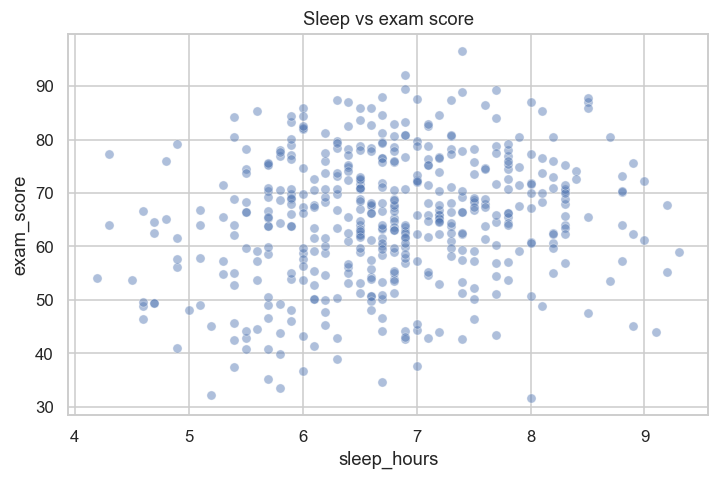

correlation r = 0.18


In [3]:
d = df.dropna(subset=["sleep_hours", "exam_score"])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.scatterplot(data=d, x="sleep_hours", y="exam_score", alpha=0.45, ax=ax)
ax.set_title("Sleep vs exam score"); plt.show()
print("correlation r =", round(d["sleep_hours"].corr(d["exam_score"]), 2))

,count,mean
sleep_hours,,
"(0.0, 5.0]",20,58.6
"(5.0, 5.5]",30,59.1
"(5.5, 6.0]",67,64.0
"(6.0, 6.5]",79,66.0
"(6.5, 7.0]",102,65.2
"(7.0, 8.0]",121,67.5
"(8.0, 10.0]",50,67.3


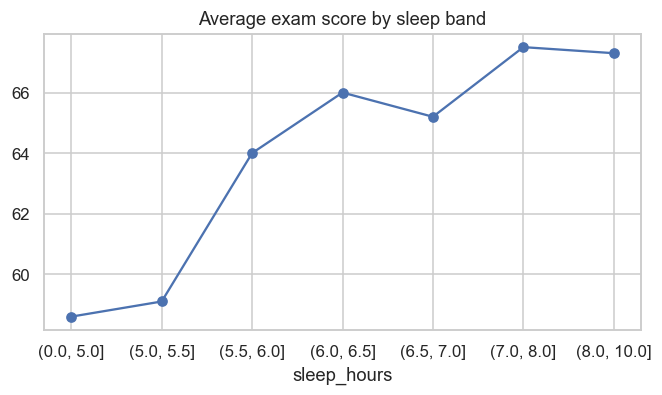

In [4]:
# Average score for each sleep band — where does the curve bend?
bands = pd.cut(d["sleep_hours"], bins=[0, 5, 5.5, 6, 6.5, 7, 8, 10])
table = d.groupby(bands)["exam_score"].agg(["count", "mean"]).round(1)
display(table)
table["mean"].plot(marker="o", figsize=(7, 3.5), title="Average exam score by sleep band"); plt.show()

In [5]:
THRESHOLD = 6          # 👈 try other values (5, 5.5, 6.5, 7). Which one separates the groups best?
short = d["sleep_hours"] < THRESHOLD
print(f"share of students below {THRESHOLD}h: {short.mean():.0%}")
print(d.groupby(short)["exam_score"].mean().round(1).rename({True: f"< {THRESHOLD}h", False: f">= {THRESHOLD}h"}))

share of students below 6h: 22%
sleep_hours
>= 6h    66.4
< 6h     61.1
Name: exam_score, dtype: float64


---
# 😰 Mission 2 — The Stress Sweet Spot
**Stakeholder:** Director of Campus Counselling
**Question:** *"Students say 'stress ruins my grades'. Is that true? Is some stress good? When should we step in?"*
**EDA skills:** non-linear relationships · why a weak `r` ≠ "no relationship" · small-sample caution

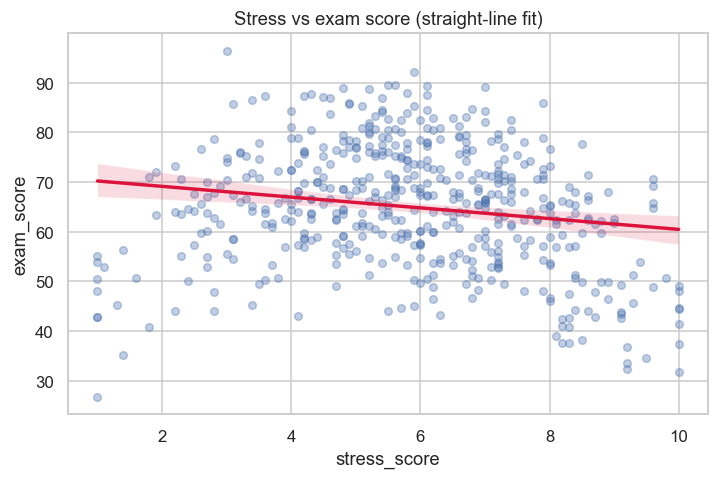

correlation r = -0.17


In [6]:
d = df.dropna(subset=["stress_score", "exam_score"])
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.regplot(data=d, x="stress_score", y="exam_score", scatter_kws={"alpha": 0.35, "s": 25},
            line_kws={"color": "crimson"}, ax=ax)
ax.set_title("Stress vs exam score (straight-line fit)"); plt.show()
print("correlation r =", round(d["stress_score"].corr(d["exam_score"]), 2))

,count,mean
stress_score,,
"(0, 2]",16,50.5
"(2, 3]",32,64.0
"(3, 4]",42,67.2
"(4, 5]",75,68.8
"(5, 6]",105,69.9
"(6, 7]",91,67.3
"(7, 8]",75,65.0
"(8, 9]",45,55.6
"(9, 10]",24,47.2


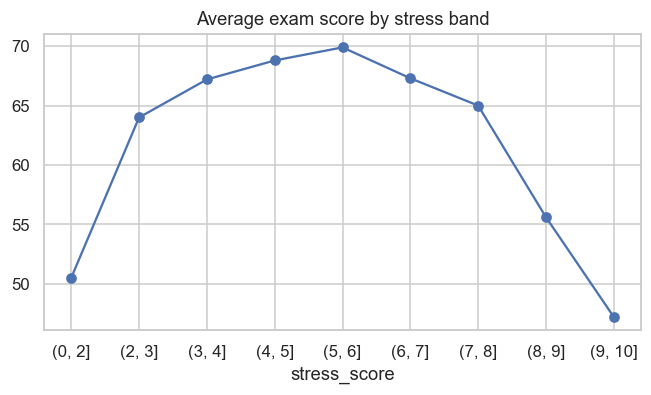

In [7]:
# Does a straight line describe it well? Average score for each stress level:
bands = pd.cut(d["stress_score"], bins=[0, 2, 3, 4, 5, 6, 7, 8, 9, 10])
table = d.groupby(bands)["exam_score"].agg(["count", "mean"]).round(1)
display(table)
table["mean"].plot(marker="o", figsize=(7, 3.5), title="Average exam score by stress band"); plt.show()

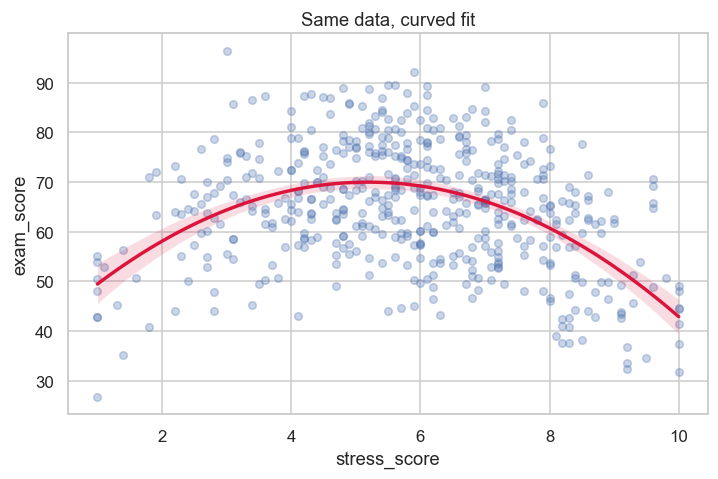

In [8]:
# Try a curve instead of a line (order=2 means a parabola):
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.regplot(data=d, x="stress_score", y="exam_score", order=2, scatter_kws={"alpha": 0.3, "s": 25},
            line_kws={"color": "crimson"}, ax=ax)
ax.set_title("Same data, curved fit"); plt.show()

---
# 💼 Mission 3 — The Working Student
**Stakeholder:** Dean of Student Finance (decides the cap on campus job hours)
**Question:** *"Does working a part-time job hurt exam scores? If so, at how many hours per week does it start to hurt?"*
**EDA skills:** bimodal variable · grouping into buckets · checking a confounder

,count,mean
job_group,,
none,277,67.2
1-8h,37,64.5
9-15h,96,65.8
>15h,108,58.4


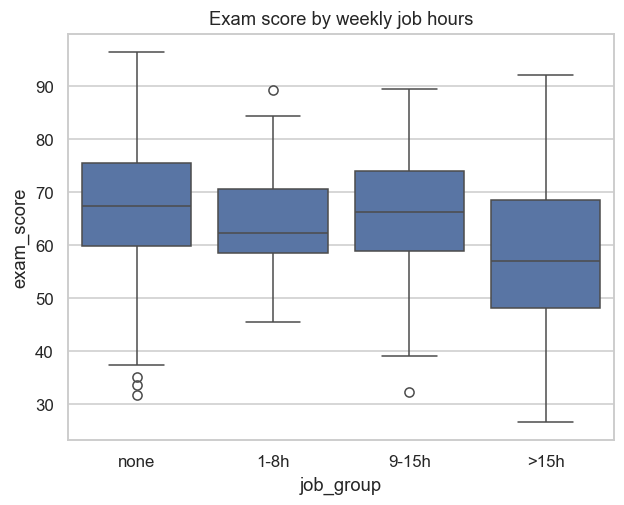

In [9]:
d = df.dropna(subset=["exam_score"]).copy()
d["job_group"] = pd.cut(d["part_time_job_hours_week"], bins=[-1, 0, 8, 15, 40],
                        labels=["none", "1-8h", "9-15h", ">15h"])
display(d.groupby("job_group")["exam_score"].agg(["count", "mean"]).round(1))
sns.boxplot(data=d, x="job_group", y="exam_score"); plt.title("Exam score by weekly job hours"); plt.show()

In [10]:
# 👈 Change the cut points above (e.g. [-1, 0, 10, 12, 15, 18, 40]) to find where the drop STARTS.
# Skeptic's check: maybe the workers are all in one hard program? Compare within each program:
d.pivot_table(index="program", columns="job_group", values="exam_score", aggfunc="mean").round(1)

job_group,none,1-8h,9-15h,>15h
program,,,,
Business,72.3,69.7,73.2,63.4
Data Science,64.3,60.0,62.6,52.3
Design,80.9,77.5,79.0,74.3
Engineering,56.7,58.0,54.1,47.5


In [11]:
# How many students are actually in the risky group?
print(d["job_group"].value_counts(normalize=True).round(2))

job_group
none     0.53
>15h     0.21
9-15h    0.19
1-8h     0.07
Name: proportion, dtype: float64


---
# ☕ Mission 4 — The Coffee Myth
**Stakeholder:** Campus Café Manager & Wellness Office
**Question:** *"Heavy coffee drinkers seem to score worse. Should we launch an anti-coffee campaign or restrict sales of espresso?"*
**EDA skills:** confounding · checking inside groups · Simpson-style thinking

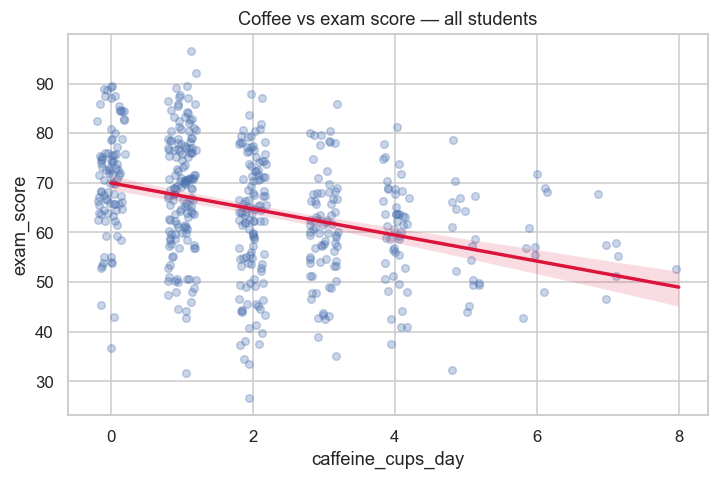

overall r = -0.34


In [12]:
d = df.dropna(subset=["exam_score"])
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.regplot(data=d, x="caffeine_cups_day", y="exam_score", x_jitter=0.2,
            scatter_kws={"alpha": 0.3, "s": 25}, line_kws={"color": "crimson"}, ax=ax)
ax.set_title("Coffee vs exam score — all students"); plt.show()
print("overall r =", round(d["caffeine_cups_day"].corr(d["exam_score"]), 2))

In [13]:
# Who drinks the most coffee? Look at the groups:
display(d.groupby("program").agg(students=("student_id", "count"),
                                  avg_cups=("caffeine_cups_day", "mean"),
                                  avg_score=("exam_score", "mean")).round(2))

,students,avg_cups,avg_score
program,,,
Business,156,1.40,70.11
Data Science,137,2.14,61.41
Design,82,0.90,78.89
Engineering,143,2.92,54.57


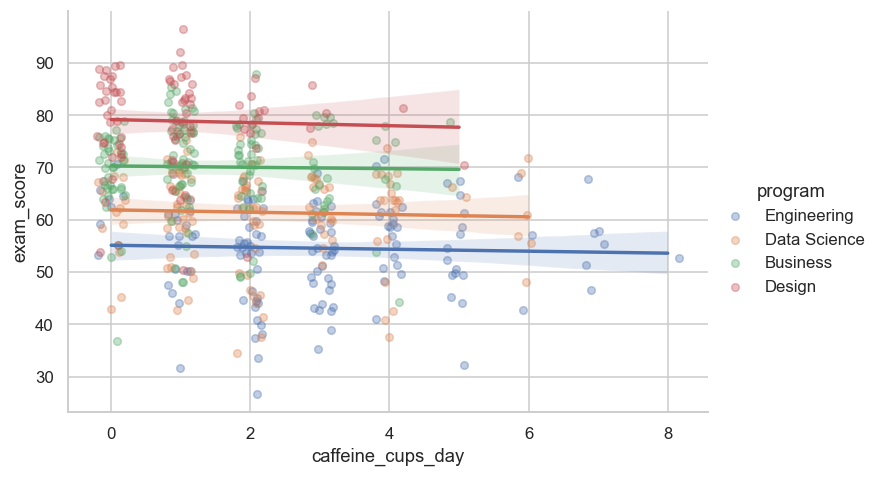

{'Business': -0.02, 'Data Science': -0.04, 'Design': -0.03, 'Engineering': -0.04}


In [14]:
# Same chart, coloured by program, and the correlation INSIDE each program
sns.lmplot(data=d, x="caffeine_cups_day", y="exam_score", hue="program", height=4.5, aspect=1.5,
           x_jitter=0.2, scatter_kws={"alpha": 0.35, "s": 25}); plt.show()
print({p: round(float(g["caffeine_cups_day"].corr(g["exam_score"])), 2) for p, g in d.groupby("program")})

---
# 🕳️ Mission 5 — Who Didn't Answer? (and the extreme students)
**Stakeholder:** Survey Office
**Question:** *"About 10 % of students skipped the sleep question. Can we just ignore the blanks? And what should we do with the extreme students (55+ study hours; 96 % score with 2 study hours)?"*
**EDA skills:** missing-data patterns · outlier judgement

In [15]:
d = df.copy()
d["sleep_missing"] = d["sleep_hours"].isna()
print("share of sleep answers missing:", round(d["sleep_missing"].mean(), 3))
d.groupby("sleep_missing")[["part_time_job_hours_week", "study_hours_week", "stress_score", "exam_score",
                            "commute_minutes"]].mean().round(1)

share of sleep answers missing: 0.094


,part_time_job_hours_week,study_hours_week,stress_score,exam_score,commute_minutes
sleep_missing,,,,,
False,6.4,18.2,5.9,65.3,36.3
True,12.3,18.7,5.7,61.2,46.9


In [16]:
# Does the missing rate change by group?
d["job_group"] = pd.cut(d["part_time_job_hours_week"], bins=[-1, 0, 15, 40], labels=["no job", "1-15h", ">15h"])
for col in ["job_group", "program", "residence"]:
    print(d.groupby(col)["sleep_missing"].mean().round(3).to_frame("share missing"), "\n")

           share missing
job_group               
no job             0.032
1-15h              0.149
>15h               0.185 

              share missing
program                    
Business              0.090
Data Science          0.080
Design                0.072
Engineering           0.126 

           share missing
residence               
Commuter           0.120
Home               0.104
Hostel             0.072 



In [17]:
# The extreme students: error or real?
extreme = d[(d["study_hours_week"] >= 50) | ((d["exam_score"] >= 93) & (d["study_hours_week"] <= 5))]
extreme[["student_id", "program", "study_hours_week", "sleep_hours", "stress_score", "exam_score"]]

,student_id,program,study_hours_week,sleep_hours,stress_score,exam_score
108,CS-0109,Data Science,55.0,7.4,9.6,69.2
182,CS-0183,Data Science,58.0,7.7,9.6,65.8
186,CS-0187,Design,2.0,7.4,3.0,96.5
476,CS-0477,Engineering,61.0,5.8,9.6,70.6


In [18]:
# Compare them with their own program (are they consistent with the rest of their record?)
d.groupby("program")[["study_hours_week", "stress_score", "exam_score"]].mean().round(1)

,study_hours_week,stress_score,exam_score
program,,,
Business,14.0,5.9,70.1
Data Science,20.7,5.9,61.4
Design,8.7,5.0,78.9
Engineering,26.2,6.2,54.6


---
# 🔑 GROUND TRUTH — computed numbers for each mission
*(instructor only — values below are printed by the code, so they always match the data)*

In [19]:
d = df.dropna(subset=["sleep_hours", "exam_score"])
below, above = d[d.sleep_hours < 6]["exam_score"], d[d.sleep_hours >= 6]["exam_score"]
print("=== TEAM 1 SLEEP ===")
print(f"overall r = {d.sleep_hours.corr(d.exam_score):.2f}   (weak-looking)")
print(f"<6h: n={len(below)} ({len(below)/len(d):.0%} of students) mean={below.mean():.1f}   >=6h: n={len(above)} mean={above.mean():.1f}   gap={above.mean()-below.mean():.1f} pts")
print(d.groupby(pd.cut(d.sleep_hours,[0,5,5.5,6,6.5,7,8,10]))["exam_score"].agg(["count","mean"]).round(1))

=== TEAM 1 SLEEP ===
overall r = 0.18   (weak-looking)
<6h: n=101 (22% of students) mean=61.1   >=6h: n=368 mean=66.4   gap=5.3 pts
             count  mean
sleep_hours             
(0.0, 5.0]      20  58.6
(5.0, 5.5]      30  59.1
(5.5, 6.0]      67  64.0
(6.0, 6.5]      79  66.0
(6.5, 7.0]     102  65.2
(7.0, 8.0]     121  67.5
(8.0, 10.0]     50  67.3


In [20]:
d = df.dropna(subset=["stress_score", "exam_score"])
print("=== TEAM 2 STRESS ===")
print(f"overall r = {d.stress_score.corr(d.exam_score):.2f}   (weak — but the relationship is strong and CURVED)")
t = d.groupby(pd.cut(d.stress_score,[0,2,3,4,5,6,7,8,9,10]))["exam_score"].agg(["count","mean"]).round(1)
print(t)
print("peak band:", t["mean"].idxmax(), "->", t["mean"].max())

=== TEAM 2 STRESS ===
overall r = -0.17   (weak — but the relationship is strong and CURVED)
              count  mean
stress_score             
(0, 2]           16  50.5
(2, 3]           32  64.0
(3, 4]           42  67.2
(4, 5]           75  68.8
(5, 6]          105  69.9
(6, 7]           91  67.3
(7, 8]           75  65.0
(8, 9]           45  55.6
(9, 10]          24  47.2
peak band: (5, 6] -> 69.9


In [21]:
d = df.dropna(subset=["exam_score"]).copy()
d["jg"] = pd.cut(d.part_time_job_hours_week, bins=[-1,0,8,15,40], labels=["none","1-8h","9-15h",">15h"])
print("=== TEAM 3 JOB ===")
print(d.groupby("jg")["exam_score"].agg(["count","mean"]).round(1))
print("share >15h:", round((d.part_time_job_hours_week>15).mean(),2))
print(d.pivot_table(index="program", columns="jg", values="exam_score", aggfunc="mean").round(1))
print("avg sleep >15h vs <=15h:", d[d.part_time_job_hours_week>15].sleep_hours.mean().round(2), d[d.part_time_job_hours_week<=15].sleep_hours.mean().round(2))

=== TEAM 3 JOB ===
       count  mean
jg                
none     277  67.2
1-8h      37  64.5
9-15h     96  65.8
>15h     108  58.4
share >15h: 0.21
jg            none  1-8h  9-15h  >15h
program                              
Business      72.3  69.7   73.2  63.4
Data Science  64.3  60.0   62.6  52.3
Design        80.9  77.5   79.0  74.3
Engineering   56.7  58.0   54.1  47.5
avg sleep >15h vs <=15h: 6.15 6.9


In [22]:
d = df.dropna(subset=["exam_score"])
print("=== TEAM 4 COFFEE ===")
print("overall r =", round(d.caffeine_cups_day.corr(d.exam_score), 2))
print(d.groupby("program").agg(avg_cups=("caffeine_cups_day","mean"), avg_score=("exam_score","mean")).round(2))
print("within-program r:", {p: round(float(g.caffeine_cups_day.corr(g.exam_score)),2) for p, g in d.groupby("program")})

=== TEAM 4 COFFEE ===
overall r = -0.34
              avg_cups  avg_score
program                          
Business          1.40      70.11
Data Science      2.14      61.41
Design            0.90      78.89
Engineering       2.92      54.57
within-program r: {'Business': -0.02, 'Data Science': -0.04, 'Design': -0.03, 'Engineering': -0.04}


In [23]:
d = df.copy(); d["miss"] = d.sleep_hours.isna()
print("=== TEAM 5 MISSING + OUTLIERS ===")
print("missing share:", round(d.miss.mean(),3))
d["jg"] = pd.cut(d.part_time_job_hours_week, bins=[-1,0,15,40], labels=["no job","1-15h",">15h"])
print(d.groupby("jg")["miss"].mean().round(3).to_dict(), "| by program:", d.groupby("program")["miss"].mean().round(3).to_dict())
print(d.groupby("residence")["miss"].mean().round(3).to_dict())
print(d[(d.study_hours_week>=50)|((d.exam_score>=93)&(d.study_hours_week<=5))][["student_id","program","study_hours_week","stress_score","exam_score"]])

=== TEAM 5 MISSING + OUTLIERS ===
missing share: 0.094
{'no job': 0.032, '1-15h': 0.149, '>15h': 0.185} | by program: {'Business': 0.09, 'Data Science': 0.08, 'Design': 0.072, 'Engineering': 0.126}
{'Commuter': 0.12, 'Home': 0.104, 'Hostel': 0.072}
    student_id       program  study_hours_week  stress_score  exam_score
108    CS-0109  Data Science              55.0           9.6        69.2
182    CS-0183  Data Science              58.0           9.6        65.8
186    CS-0187        Design               2.0           3.0        96.5
476    CS-0477   Engineering              61.0           9.6        70.6


### Quick answers
| Team | Finding | Common mistake | Strong recommendation |
|---|---|---|---|
| **1 Sleep** | A *cliff* below ~6 h: students under 6 h (≈22 % of the class) average ≈5 pts lower overall, and ≈8 pts lower under 5.5 h (≈59 vs ≈66+); above 6 h extra sleep adds little. `r` (≈0.18) understates it because the relation is a threshold, not a line. | "Sleep and scores are weakly related." | "Recommend ≥ 6 h; target the ~25 % below it." |
| **2 Stress** | **Inverted U**: scores peak at moderate stress (≈5–6) and fall at both ends, steeply above ~8. Pearson r ≈ −0.17 hides it. Lowest-stress band is tiny (n≈16) → be careful. | "Stress is weakly bad." / treating low-stress as proven harmful. | "Intervene at stress ≥ 8; don't try to eliminate stress." |
| **3 Job** | No harm up to ~15 h/week; above 15 h scores drop (≈58 vs ≈67 for non-workers, ≈ −9 pts; ≈21 % of students), and it falls even more above ~22 h. Holds within each program. Overworked students also sleep less (≈6.2 h vs 6.9 h). | Comparing "works vs doesn't" and concluding any job hurts. | "Cap campus jobs at ~15 h/week." |
| **4 Coffee** | Overall r ≈ −0.34, but **inside every program ≈ 0**. Engineering drinks the most and scores lowest because of the *program*. Confounding. | "Coffee lowers scores → ban it." | "No coffee campaign; compare within program." |
| **5 Missing/outliers** | Sleep is missing ≈ 5× more often for students with a job (≈3 % of non-workers vs 15–19 % of workers) → the sleep results *under-represent* overworked students (biased, probably *understating* sleep trouble). The 3 grinders (55–61 h, stress ≈9.6) and the 96.5 Design student are coherent → **keep & flag**. | "Fill blanks with the mean." / "delete outliers." | "Follow up with job-heavy students; keep outliers; add an optional-question reminder." |